## Task 1: Vision-Language Model Exploration - Video Captioning

Select a short, publicly available video (maximum 2 minutes) from platforms like YouTube or Vimeo. Share the link to the video in your submission. Implement a video captioning system using a pre-trained and lightweight Vision-Language Model. You may use libraries such as Hugging Face Transformers or any other suitable framework. Provide a description of the video content generated by your model. Discuss the challenges faced while implementing the solution and how you addressed them.



### Problem observations

1. I have heard of Image Captioning; which in simple terms means Image input text output but, here the difference comes in video is a motion of images so that made me think. And video captioning is not just image captioning repeated many times, so the model must understand both, what is present in individual frames and how do those frames change over time. That makes frame selection and ordering important.

2. Constraint was to use lightweight VLM and that made me realize this is a direct use of huggingface's own SmolVLM. Although I looked into [Cog from z.ai](https://huggingface.co/zai-org/cogvlm2-llama3-caption) but it requires ~16GB VRAM which google colab doesn't provide for free. SmolVLM only needs ~4.5GB VRAM. 

3. The task is a balance between output accuracy and processing efficiency, capturing every frame is unnecessary and expensive, but having not enough information may miss the point of the video. Thus, this was a challenge to handle.

### Result observations

1. Caption quality depended on both, the frame sampling and prompt design, different frame counts changed whether the model captured motion, scene flow, or only isolated objects.

2. More frames did not always mean better captions, too many frames increased the input length, memory usage, and token pressure without improving the final result proportionally. For SmolVLM generally 8 frames was good, while 16 blew up the context window and 12 did not yield good results.

3. This model produced a useful high-level description, but not perfect detail. I realized that lightweight VLMs are good for summarizing the overall scene, but they may miss fine-grained actions or rapid transitions.

4. I also observed that prompting mattered almost as much as the frames and thereby the same video can produce noticeably different captions depending on how the prompt was written, because the model may focus on objects, actions, scene context, or summary style depending on the instruction.

5. For language models there are certain hyperparameters that we can change which affected the output. In the first problem I tried 2 solutions first, I tried without sampling and without setting a temperature and in the [second](./Coding_Challenge_1_Video_Captioning_2.ipynb) I added sampling and set the temperature to 0.6 and also changed the promt which allowed for more creative freedom.

### Solution strategy & challenges

1. My initial strategy was to extract the frame by sampling every n seconds but, that would lead to clipping of the video. So, I revised my strategy to uniform sampling.

2. I used an equally spaced frame sampling to represent the full video efficiently thus, still covering the beginning, middle, and end of the video.

3. I kept number of frames small to fit the model and memory constraints, a lightweight model can only handle a limited amount of visual context, so a small frame budget was necessary.

4. I kept the pipeline simple to reduce failure points which made the solution easier to reproduce in Colab.

5. I had to process the video while downloading them, downloaded videos need to be converted to `libx264` before OpenCV can process them.

6. One major challenge I faced while setting up the model was choosing the correct data type for pytorch, the default float32 is too large for many GPUs the recommended AI optimized bfloat16 also led to problems in loading it caused crashes of the runtime. so, I finally chose to go with float16 which works reliably, along with going for float16 I also turned on two settings first, low_cpu_mem_usage for the model itself second was the pytorch's environment setting for expandable segments. These settings helped with better memory management when loading models and running them on a single GPU.


In [1]:
!pip install yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/182.3 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/3.3 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 3.3/3.3 MB 107.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 69.5 MB/s eta 0:00:00


In [2]:
!yt-dlp -f "best[height<=720][ext=mp4]" \
        --recode-video mp4 \
        --postprocessor-args "ffmpeg:-c:v libx264 -preset fast -crf 23" \
        "https://www.youtube.com/shorts/CkaWa0BJbec" \
        -o "/content/fixed_output.mp4"

[youtube] Extracting URL: https://www.youtube.com/shorts/CkaWa0BJbec
[youtube] CkaWa0BJbec: Downloading webpage
[youtube] CkaWa0BJbec: Downloading android vr player API JSON
[info] CkaWa0BJbec: Downloading 1 format(s): 18
[download] Destination: /content/fixed_output.mp4
[download] 100% of    3.78MiB in 00:00:00 at 19.49MiB/s
[VideoConvertor] Not converting media file "/content/fixed_output.mp4"; already is in target format mp4


### Video Link: <https://www.youtube.com/shorts/CkaWa0BJbec>

### Turning on Expandable Segments, a PyTorch setting to allow it to use the GPU's memory in a dynamic fashion

In [3]:
!pip -q install transformers accelerate opencv-python pillow

import os

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [4]:
import cv2
import gc
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText
gc.collect()
torch.cuda.empty_cache()

MODEL_ID = "HuggingFaceTB/SmolVLM-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID)

model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.49G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/92.0 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
        (position_embedding): Embedding(729, 1152)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-26): 27 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
            )
            (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_feature

### Seeing the device of the model to ensure that it loads on the GPU

In [5]:
model.device

device(type='cuda', index=0)

### Frame extraction logic

Take all the frame count, and then take the evenly spaced samples of the entire video for inference.

In [ ]:
VIDEO_PATH = "/content/fixed_output.mp4"

import numpy as np

def extract_frames(video_path, max_frames=8, resize=None):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    print(f"Video FPS: {fps}, total frames: {total_frames}, duration: {total_frames/fps:.2f}s")

    if total_frames <= 0:
        cap.release()
        raise ValueError("Could not read total frame count.")

    n_samples = min(max_frames, total_frames)
    target_indices = set(np.linspace(0, total_frames - 1, n_samples, dtype=int).tolist())

    frames = []
    timestamps = []
    frame_idx = 0
    frame_printed = False

    while True:
        ret, frame = cap.read()
        if not ret:
            print(f"Frame? {ret}")
            break

        if frame_idx in target_indices:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(rgb)
            if not frame_printed:
                frame_printed = True
                print(f"Frame original size: {img.size}")
            if resize is not None:
                img = img.resize(resize)

            frames.append(img)
            timestamps.append(frame_idx / fps)

            if len(frames) == n_samples:
                break

        frame_idx += 1

    cap.release()
    return frames, timestamps

frames, timestamps = extract_frames(VIDEO_PATH, max_frames=12, resize=(360, 640))
print(f"Extracted {len(frames)} frames, timestamps: {timestamps}")

Video FPS: 30.0, total frames: 1593, duration: 53.10s
Frame original size: (360, 640)
Extracted 12 frames, timestamps: [0.0, 4.8, 9.633333333333333, 14.466666666666667, 19.266666666666666, 24.1, 28.933333333333334, 33.766666666666666, 38.56666666666667, 43.4, 48.233333333333334, 53.06666666666667]


In [7]:
len(frames)

12

### Visualizing the extracted frames

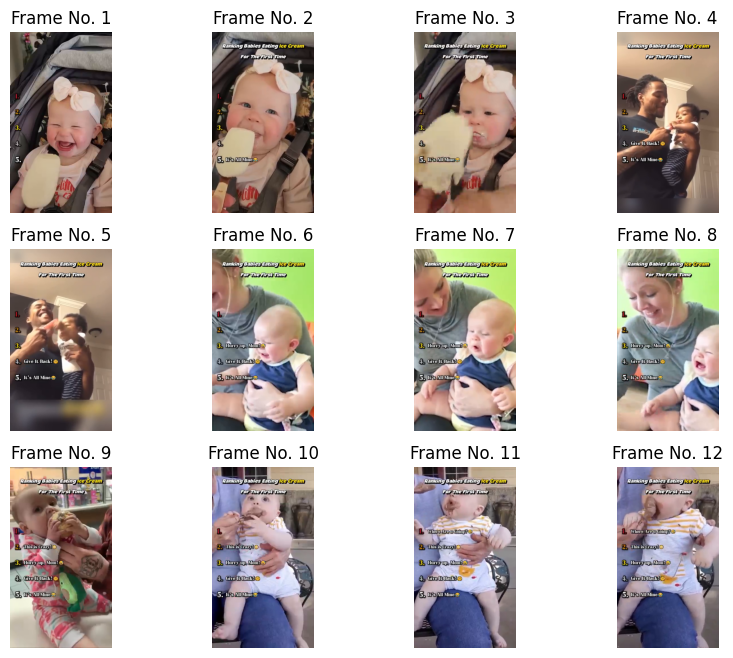

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 8), nrows=3, ncols=4)
for i, a in zip(np.arange(1, 13), ax.flatten()):
    a.set_title(f"Frame No. {i}")
    a.imshow(frames[i-1])
    a.axis('off')
plt.show()

In [9]:
# SmolVLM multi-image prompt for video captioning
messages = [{
    "role": "user",
    "content": [
        {"type": "image"} for _ in frames
    ] + [{
        "type": "text",
        "text": "Caption this sequence of images from a video"
    }]
}]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=frames, return_tensors="pt").to(model.device)

with torch.inference_mode():
    generated_ids = model.generate(**inputs, max_new_tokens=200, do_sample=False)
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("Done")

Done


In [10]:
caption

'User:<row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_col_2><row_3_col_3>\n<row_4_col_1><row_4_col_2><row_4_col_3>\n\n<global-img><row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_col_2><row_3_col_3>\n<row_4_col_1><row_4_col_2><row_4_col_3>\n\n<global-img><row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_col_2><row_3_col_3>\n<row_4_col_1><row_4_col_2><row_4_col_3>\n\n<global-img><row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_col_2><row_3_col_3>\n<row_4_col_1><row_4_col_2><row_4_col_3>\n\n<global-img><row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_col_2><row_3_col_3>\n<row_4_col_1><row_4_col_2><row_4_col_3>\n\n<global-img><row_1_col_1><row_1_col_2><row_1_col_3>\n<row_2_col_1><row_2_col_2><row_2_col_3>\n<row_3_col_1><row_3_co

### Final output :)

In [11]:
from IPython.display import Markdown, display_markdown

display_markdown(Markdown(f'## {caption.split("\nAssistant:")[-1][1:]}'))

## A baby is being held by an adult and eating ice cream.